In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
raw_df = pd.read_csv("cumulative_2026.03.09_14.43.47.csv", comment="#")
# storing candidates separately for testing at the end
temp_df = raw_df.copy()

# removing leakage - they contain the answer for the classifier already, as well as admin/meta info
temp_df = temp_df.drop(columns=["koi_score", "koi_pdisposition", "koi_fpflag_nt", "koi_fpflag_ss", 
                      "koi_fpflag_co", "koi_fpflag_ec", "koi_disp_prov", "koi_vet_stat", 
                      "koi_vet_date", "koi_comment"])
# keep for later but don't need in the df itself
df_misc = temp_df[["kepid", "kepoi_name", "kepler_name"]]
temp_df = temp_df.drop(columns=["kepid", "kepoi_name", "kepler_name"])
# other non-useful data to drop
temp_df = temp_df.drop(columns=["koi_quarters", "koi_tce_plnt_num", "koi_tce_delivname", "ra", "dec"])
# more irrelavant data
temp_df = temp_df.drop(columns=[
    'koi_time0bk', 'koi_time0',
    'koi_eccen', 'koi_longp',
    'koi_fittype', 'koi_limbdark_mod', 'koi_trans_mod', 'koi_parm_prov', 'koi_sparprov',
    'koi_ldm_coeff1', 'koi_ldm_coeff2', 'koi_ldm_coeff3', 'koi_ldm_coeff4',
    'koi_datalink_dvr', 'koi_datalink_dvs',
    'koi_fwm_stat_sig', 'koi_fwm_sra', 'koi_fwm_sdec', 'koi_fwm_srao',
    'koi_fwm_sdeco', 'koi_fwm_prao', 'koi_fwm_pdeco',
    'koi_dicco_mra', 'koi_dicco_mdec', 'koi_dicco_msky',
    'koi_dikco_mra', 'koi_dikco_mdec', 'koi_dikco_msky',
    'koi_count',
    'koi_kepmag', 'koi_gmag', 'koi_rmag', 'koi_imag',
    'koi_zmag', 'koi_jmag', 'koi_hmag', 'koi_kmag'
])

# these 4 columns only have null values anyways
temp_df = temp_df.drop(columns=["koi_sage", "koi_ingress", "koi_model_chisq", "koi_model_dof"])


In [29]:
df_cand = temp_df[temp_df["koi_disposition"] == "CANDIDATE"]
df = temp_df[temp_df["koi_disposition"] != "CANDIDATE"]

In [125]:
# Significantly more false positives than confirmed, so I'll have to do some filtering later.
raw_df['koi_disposition'].value_counts()

koi_disposition
FALSE POSITIVE    4839
CONFIRMED         2746
CANDIDATE         1979
Name: count, dtype: int64

In [5]:
df.describe()

,rowid,koi_period,koi_impact,koi_duration,koi_depth,koi_ror,koi_srho,koi_prad,koi_sma,koi_incl,...,koi_max_sngle_ev,koi_max_mult_ev,koi_model_snr,koi_num_transits,koi_bin_oedp_sig,koi_steff,koi_slogg,koi_smet,koi_srad,koi_smass
count,7585.000000,7585.000000,7326.000000,7585.000000,7.326000e+03,7326.000000,7366.000000,7326.000000,7326.000000,7325.000000,...,6904.000000,6904.000000,7326.000000,6904.000000,6675.000000,7326.000000,7326.000000,7306.000000,7326.000000,7326.000000
mean,4562.428609,51.660971,0.756127,5.713065,2.952961e+04,0.293333,6.958481,104.169379,0.190266,81.227089,...,213.510645,1242.699160,318.594049,419.015353,0.387775,5715.973928,4.310837,-0.127553,1.752564,1.023282
std,2799.120819,111.838381,3.196379,6.826210,9.117009e+04,3.155387,48.264383,3180.483497,0.291215,16.391955,...,846.966472,4559.010980,881.096351,568.780061,0.524042,819.235213,0.437200,0.282215,6.279191,0.353275
min,1.000000,0.241843,0.000000,0.104600,8.000000e-01,0.001289,0.000040,0.080000,0.005900,2.290000,...,2.538761,7.105086,0.000000,0.000000,-1.000000,2661.000000,0.047000,-2.500000,0.116000,0.000000
25%,2104.000000,2.243041,0.227000,2.474300,1.826500e+02,0.013230,0.183103,1.500000,0.033400,82.050000,...,4.223582,12.903739,15.400000,46.000000,0.105900,5313.000000,4.218000,-0.260000,0.829000,0.843250
50%,4440.000000,8.073941,0.586000,3.836000,5.015000e+02,0.023843,0.791455,2.620000,0.075550,88.020000,...,6.222944,24.091312,30.500000,164.000000,0.467800,5774.000000,4.438000,-0.100000,1.000000,0.973000
75%,6945.000000,30.552897,0.917000,6.271000,2.319050e+03,0.197202,2.440615,24.185000,0.177475,89.640000,...,26.454360,122.105037,114.775000,549.000000,0.810350,6116.750000,4.543000,0.070000,1.346750,1.100000
max,9564.000000,1071.232624,100.806000,138.540000,1.541400e+06,99.870651,980.854190,200346.000000,2.152500,90.000000,...,22982.162000,120049.680000,9054.700000,2664.000000,1.000000,15896.000000,5.283000,0.560000,229.908000,3.735000


In [6]:
# Need to deal with this values before training, probably imputation
df.isnull().sum().sort_values(ascending=False)

koi_bin_oedp_sig    910
koi_num_transits    681
koi_max_mult_ev     681
koi_max_sngle_ev    681
koi_smet            279
koi_incl            260
koi_model_snr       259
koi_dor             259
koi_steff           259
koi_teq             259
koi_smass           259
koi_prad            259
koi_slogg           259
koi_ror             259
koi_depth           259
koi_impact          259
koi_srad            259
koi_sma             259
koi_insol           219
koi_srho            219
koi_disposition       0
koi_duration          0
koi_period            0
rowid                 0
dtype: int64

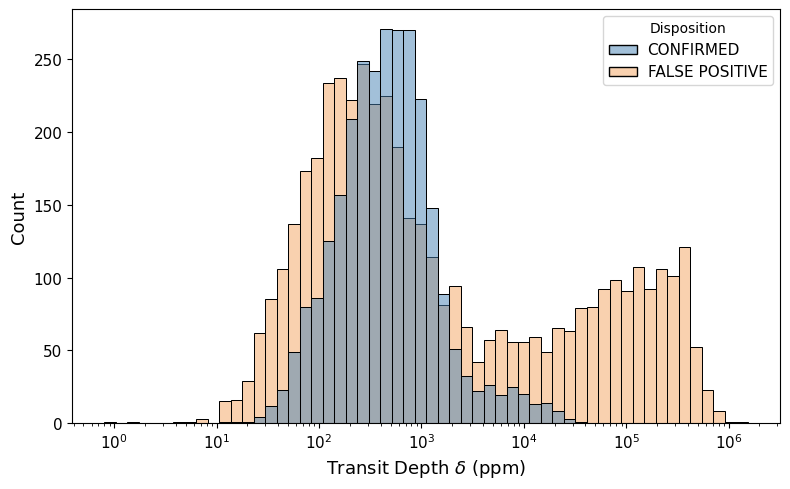

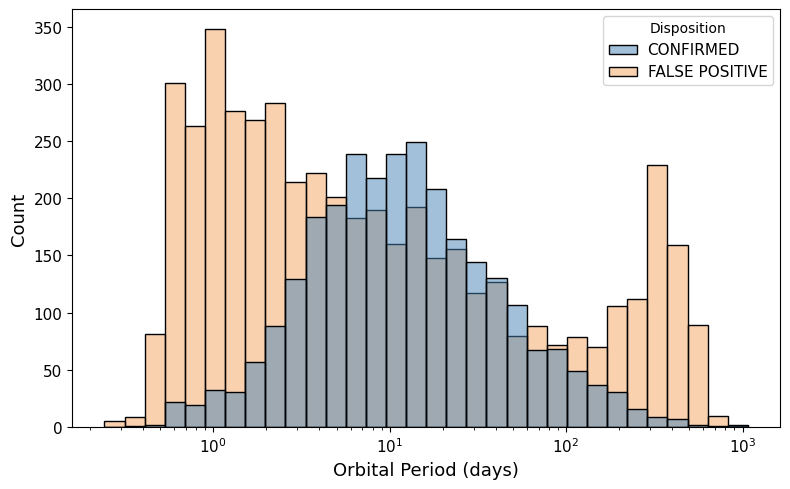

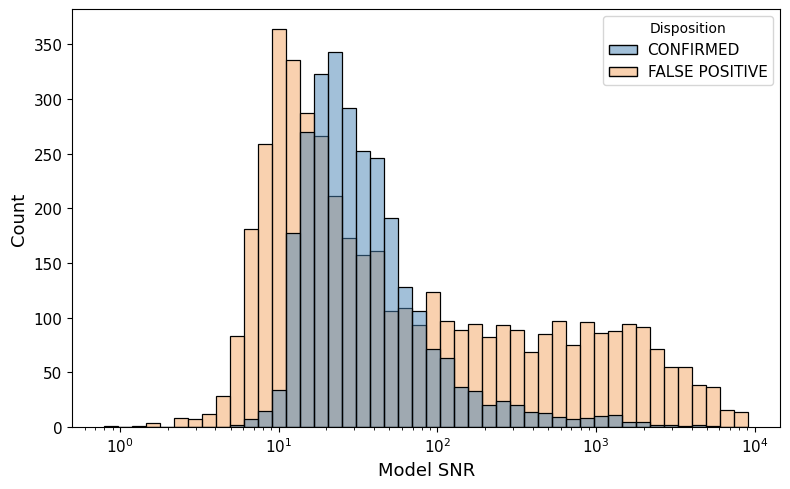

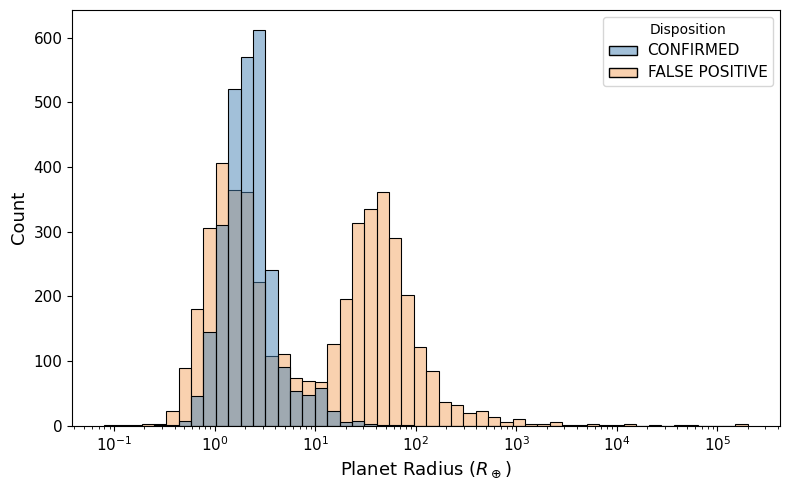

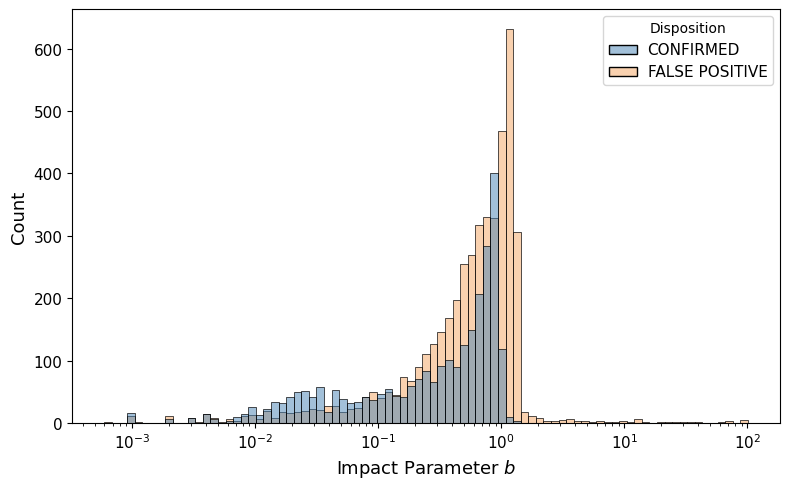

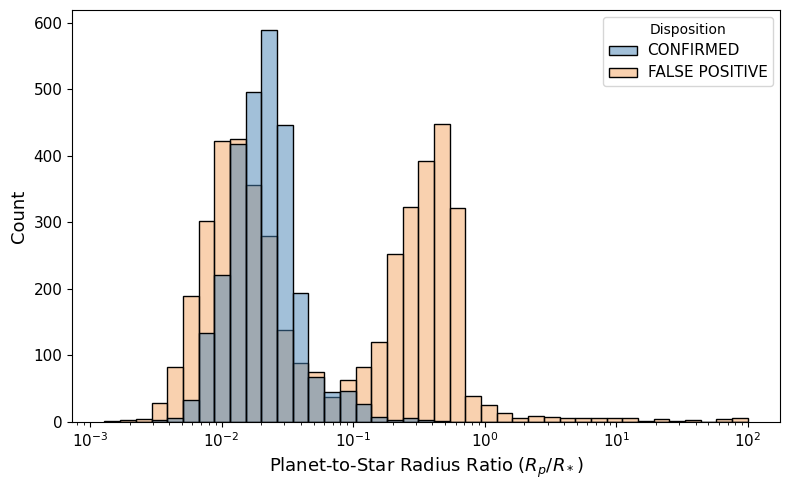

In [129]:
FEATURE_LABELS = {
    "koi_depth":     "Transit Depth $\\delta$ (ppm)",
    "koi_period":    "Orbital Period (days)",
    "koi_model_snr": "Model SNR",
    "koi_prad":      "Planet Radius ($R_\\oplus$)",
    "koi_impact":    "Impact Parameter $b$",
    "koi_ror":       "Planet-to-Star Radius Ratio ($R_p/R_*$)",
}

def histplot(data, feature, log_scale=True):
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.histplot(data=data, x=feature, log_scale=log_scale, hue="koi_disposition",
                 ax=ax, palette={"CONFIRMED": "steelblue", "FALSE POSITIVE": "sandybrown"})
    
    ax.set_xlabel(FEATURE_LABELS.get(feature, feature), fontsize=13)
    ax.set_ylabel("Count", fontsize=13)
    ax.tick_params(labelsize=11)
    
    legend = ax.get_legend()
    legend.set_title("Disposition")
    for text in legend.get_texts():
        text.set_fontsize(11)
    
    plt.tight_layout()
    plt.savefig(f"figures/eda/{feature}_histplot.pdf", dpi=300, bbox_inches="tight")
    plt.show()

# bimodal distribution for koi_depth - the higher end have lots of false positives, maybe from second stars in the system?
histplot(df, "koi_depth")
# a 10 day period is around the highest peak, there's a peak of false positive in the 300-500 day range
histplot(df, "koi_period")
# a bit counterintuitive since you might think confirmed planets would have higher signal to noise ratio
histplot(df, "koi_model_snr")
# a really clean feature, since above 10-20 times Earth radii all confirmed go away, leaving just false positives.
histplot(df, "koi_prad")
# things above b = 1 are pretty much always false positive
histplot(df, "koi_impact")
# very clean signal, but somehwhat highly correltaed with koi_prad/depth
histplot(df, "koi_ror")

In [8]:
df[df["koi_disposition"] == "CONFIRMED"]["koi_impact"].max()

df["koi_disposition"]

0            CONFIRMED
1            CONFIRMED
3       FALSE POSITIVE
4            CONFIRMED
5            CONFIRMED
             ...      
9557    FALSE POSITIVE
9558    FALSE POSITIVE
9559    FALSE POSITIVE
9561    FALSE POSITIVE
9563    FALSE POSITIVE
Name: koi_disposition, Length: 7585, dtype: str

In [9]:
# TRAINING
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

In [10]:
X = df.drop(columns=["koi_disposition", "rowid"])
y = df["koi_disposition"].replace({"CONFIRMED": 1, "FALSE POSITIVE": 0}).astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# using median imputation for the SimpleImputer because 
imputer = SimpleImputer(strategy='median')
# class_weight = 'balanced' solves the problem where there are more False positives than there are confirmed values
rfc_model = RandomForestClassifier(n_estimators=10, class_weight="balanced", random_state=42)
pipeline = Pipeline(steps=[('imputer', imputer), ('RFC_model', rfc_model)])

In [12]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Classification report", classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, pipeline.predict_proba(X_test)[:,1]))

Accuracy: 0.9235332893869479
Classification report               precision    recall  f1-score   support

           0       0.94      0.94      0.94       960
           1       0.90      0.89      0.89       557

    accuracy                           0.92      1517
   macro avg       0.92      0.92      0.92      1517
weighted avg       0.92      0.92      0.92      1517

[[907  53]
 [ 63 494]]
ROC-AUC: 0.9701694344703771


In [14]:
importances = pipeline.named_steps['RFC_model'].feature_importances_
feat_names = X.columns

<BarContainer object of 22 artists>

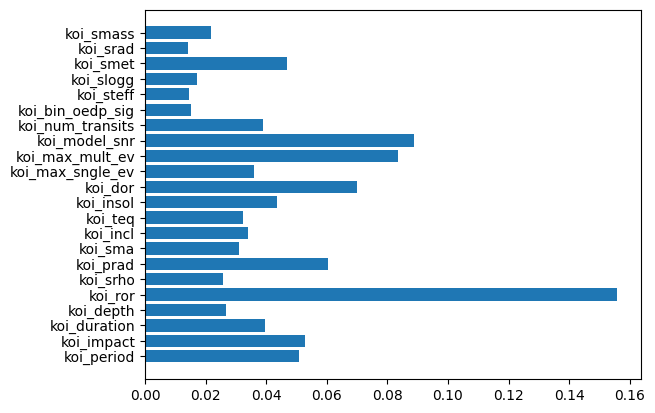

In [15]:
plt.barh(feat_names, importances)

In [16]:
unsorted = dict(zip(feat_names, importances))
feature_importances = dict(sorted(unsorted.items(), key=lambda x:x[1]))

<BarContainer object of 22 artists>

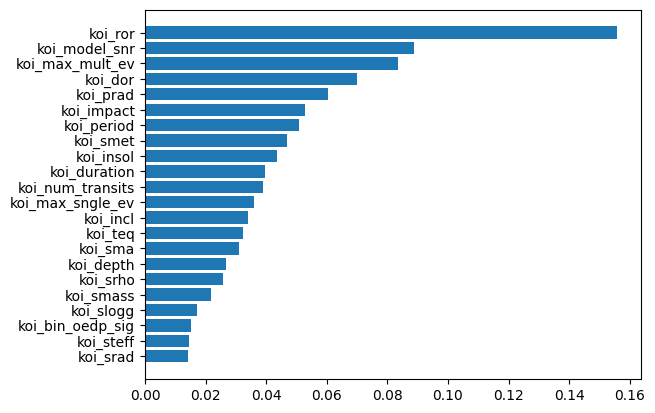

In [17]:
# koi_ror is by far the highest and best predictor
plt.barh(list(feature_importances.keys()), list(feature_importances.values()))

In [30]:
X_cand = df_cand.drop(columns=["koi_disposition", "rowid"])


In [19]:
print(X_cand.shape)
print(X.columns.tolist())
print(X_cand.columns.tolist())

(1979, 22)
['koi_period', 'koi_impact', 'koi_duration', 'koi_depth', 'koi_ror', 'koi_srho', 'koi_prad', 'koi_sma', 'koi_incl', 'koi_teq', 'koi_insol', 'koi_dor', 'koi_max_sngle_ev', 'koi_max_mult_ev', 'koi_model_snr', 'koi_num_transits', 'koi_bin_oedp_sig', 'koi_steff', 'koi_slogg', 'koi_smet', 'koi_srad', 'koi_smass']
['koi_period', 'koi_impact', 'koi_duration', 'koi_depth', 'koi_ror', 'koi_srho', 'koi_prad', 'koi_sma', 'koi_incl', 'koi_teq', 'koi_insol', 'koi_dor', 'koi_max_sngle_ev', 'koi_max_mult_ev', 'koi_model_snr', 'koi_num_transits', 'koi_bin_oedp_sig', 'koi_steff', 'koi_slogg', 'koi_smet', 'koi_srad', 'koi_smass']


In [31]:
# PREDICTING CANDIDATES

cand_pred = pipeline.predict(X_cand)

In [21]:
import numpy as np

In [32]:
print(cand_pred)
unique, counts = np.unique(cand_pred, return_counts=True)
print(dict(zip(unique, counts)))

[0 0 0 ... 0 0 0]
{np.int64(0): np.int64(1585), np.int64(1): np.int64(394)}


In [33]:
cand_prob = pipeline.predict_proba(X_cand)[:,1]
print(cand_prob)

[0.  0.3 0.3 ... 0.1 0.2 0. ]


In [34]:
df_cand

,rowid,koi_disposition,koi_period,koi_impact,koi_duration,koi_depth,koi_ror,koi_srho,koi_prad,koi_sma,...,koi_max_sngle_ev,koi_max_mult_ev,koi_model_snr,koi_num_transits,koi_bin_oedp_sig,koi_steff,koi_slogg,koi_smet,koi_srad,koi_smass
2,3,CANDIDATE,19.899140,0.969,1.7822,10829.0,0.154046,7.29555,14.60,0.1419,...,37.159767,187.449100,76.3,56.0,0.6624,5853.0,4.544,-0.18,0.868,0.961
58,59,CANDIDATE,40.419504,0.911,3.3620,6256.0,0.088069,1.89549,7.51,0.2062,...,22.598503,94.071846,36.9,36.0,0.8482,5446.0,4.507,-0.54,0.781,0.714
62,63,CANDIDATE,7.240661,1.198,0.5580,556.4,0.232818,8.66412,19.45,0.0692,...,3.275137,9.166600,13.7,168.0,0.4049,5005.0,4.595,0.14,0.765,0.850
63,64,CANDIDATE,3.435916,0.624,3.1330,23.2,0.004612,0.47024,0.55,0.0437,...,3.894302,7.433781,8.7,357.0,0.0228,5779.0,4.339,-0.06,1.087,0.941
84,85,CANDIDATE,10.181584,0.920,3.5089,5741.1,0.084708,0.38059,7.73,0.0884,...,27.099031,173.098940,183.6,129.0,0.5397,5988.0,4.541,-0.52,0.836,0.885
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9538,9539,CANDIDATE,7.268182,0.780,4.9850,46.7,0.006856,0.13021,1.66,0.0821,...,3.426690,7.831779,9.7,183.0,0.0359,6297.0,3.890,0.00,2.219,1.398
9542,9543,CANDIDATE,376.379890,0.305,13.9900,1140.0,0.031308,1.10893,3.26,1.0287,...,5.646719,7.345223,13.3,3.0,0.1431,6231.0,4.488,-0.32,0.955,1.025
9552,9553,CANDIDATE,367.947848,0.902,4.2490,1301.0,0.039795,5.58716,3.72,0.9955,...,4.872857,8.615878,10.7,4.0,0.4002,5570.0,4.561,0.07,0.855,0.971
9560,9561,CANDIDATE,1.739849,0.043,3.1140,48.5,0.006379,0.50770,0.72,0.0290,...,3.841146,8.569540,10.6,766.0,0.1374,6119.0,4.444,-0.04,1.031,1.075


In [ ]:
# putting the new predictions and probabilities in the dataframe
df_cand = temp_df[temp_df["koi_disposition"] == "CANDIDATE"]
df_cand = df_cand.drop(columns=["koi_disposition", "rowid"])
df_cand.insert(loc=2, column="prediction", value=cand_pred)
df_cand.insert(loc=2, column="prediction_prob", value=cand_prob)
df_cand.insert(loc=2, column="kepoi_name", value=df_misc["kepoi_name"].values)

koi_disp_map = {0: "NOT EXOPLANET", 1: "EXOPLANET"}
df_cand["prediction"] = df_cand["prediction"].map(koi_disp_map)

In [45]:
df_cand

,koi_period,koi_impact,prediction_prob,prediction,koi_duration,koi_depth,koi_ror,koi_srho,koi_prad,koi_sma,...,koi_max_sngle_ev,koi_max_mult_ev,koi_model_snr,koi_num_transits,koi_bin_oedp_sig,koi_steff,koi_slogg,koi_smet,koi_srad,koi_smass
2,19.899140,0.969,0.0,NOT EXOPLANET,1.7822,10829.0,0.154046,7.29555,14.60,0.1419,...,37.159767,187.449100,76.3,56.0,0.6624,5853.0,4.544,-0.18,0.868,0.961
58,40.419504,0.911,0.3,NOT EXOPLANET,3.3620,6256.0,0.088069,1.89549,7.51,0.2062,...,22.598503,94.071846,36.9,36.0,0.8482,5446.0,4.507,-0.54,0.781,0.714
62,7.240661,1.198,0.3,NOT EXOPLANET,0.5580,556.4,0.232818,8.66412,19.45,0.0692,...,3.275137,9.166600,13.7,168.0,0.4049,5005.0,4.595,0.14,0.765,0.850
63,3.435916,0.624,0.2,NOT EXOPLANET,3.1330,23.2,0.004612,0.47024,0.55,0.0437,...,3.894302,7.433781,8.7,357.0,0.0228,5779.0,4.339,-0.06,1.087,0.941
84,10.181584,0.920,0.1,NOT EXOPLANET,3.5089,5741.1,0.084708,0.38059,7.73,0.0884,...,27.099031,173.098940,183.6,129.0,0.5397,5988.0,4.541,-0.52,0.836,0.885
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9538,7.268182,0.780,0.1,NOT EXOPLANET,4.9850,46.7,0.006856,0.13021,1.66,0.0821,...,3.426690,7.831779,9.7,183.0,0.0359,6297.0,3.890,0.00,2.219,1.398
9542,376.379890,0.305,0.0,NOT EXOPLANET,13.9900,1140.0,0.031308,1.10893,3.26,1.0287,...,5.646719,7.345223,13.3,3.0,0.1431,6231.0,4.488,-0.32,0.955,1.025
9552,367.947848,0.902,0.1,NOT EXOPLANET,4.2490,1301.0,0.039795,5.58716,3.72,0.9955,...,4.872857,8.615878,10.7,4.0,0.4002,5570.0,4.561,0.07,0.855,0.971
9560,1.739849,0.043,0.2,NOT EXOPLANET,3.1140,48.5,0.006379,0.50770,0.72,0.0290,...,3.841146,8.569540,10.6,766.0,0.1374,6119.0,4.444,-0.04,1.031,1.075


In [48]:
# CROSS-VALIDATION
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='roc_auc')
print(cv_scores)
print(f"Mean ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

[0.92939269 0.97417167 0.96855101 0.99151632 0.96477442]
Mean ROC-AUC: 0.9657 (+/- 0.0203)


In [53]:
# XGBOOST MODEL COMPARISON
import xgboost as xgb
from xgboost import XGBClassifier

In [ ]:
# XGBClassifier doesn't have class_weight='balanced' like scikit-learn models, but they have alternatives with little more work
imputer = SimpleImputer(strategy='median')
xgb_model = XGBClassifier(n_estimators=100, random_state=42, scale_pos_weight = (y==0).sum()/(y==1).sum())
xgb_pipe = Pipeline(steps=[('imputer', imputer), ('xgb_model', xgb_model)])

In [59]:
xgb_pipe.fit(X_train, y_train)
y_pred = xgb_pipe.predict(X_test)

In [60]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Classification report", classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, pipeline.predict_proba(X_test)[:,1]))

Accuracy: 0.9202373104812129
Classification report               precision    recall  f1-score   support

           0       0.97      0.91      0.93       960
           1       0.85      0.94      0.90       557

    accuracy                           0.92      1517
   macro avg       0.91      0.93      0.92      1517
weighted avg       0.92      0.92      0.92      1517

[[870  90]
 [ 31 526]]
ROC-AUC: 0.9701694344703771


In [61]:
# XGBOOST CROSS-VALIDATION
cv_scores = cross_val_score(xgb_pipe, X, y, cv=5, scoring='roc_auc')
print(cv_scores)
print(f"Mean ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

[0.94159914 0.97696695 0.97297961 0.99225113 0.98043494]
Mean ROC-AUC: 0.9728 (+/- 0.0169)


In [63]:
koi_scores_cand = raw_df[raw_df["koi_disposition"] == "CANDIDATE"]["koi_score"].values
koi_scores_test = raw_df.loc[X_test.index, "koi_score"]

In [66]:
wrong_mask = y_pred != y_test.values
wrong_nasa_scores = koi_scores_test[wrong_mask]
print(wrong_mask)


[False  True  True ... False False False]


In [67]:
print(wrong_nasa_scores)

697     0.000
953     0.920
3620    0.000
6723    0.000
2197    0.424
        ...  
2181    0.000
273     0.000
3198    1.000
7328    0.000
9319    0.262
Name: koi_score, Length: 121, dtype: float64


In [69]:
raw_df.loc[3198]
raw_df.loc[3198, ['koi_ror', 'koi_prad', 'koi_depth', 'koi_impact', 'koi_model_snr', 'koi_period']]

koi_ror            0.021488
koi_prad           2.430000
koi_depth        501.400000
koi_impact         0.623000
koi_model_snr    100.300000
koi_period         3.705992
Name: 3198, dtype: float64

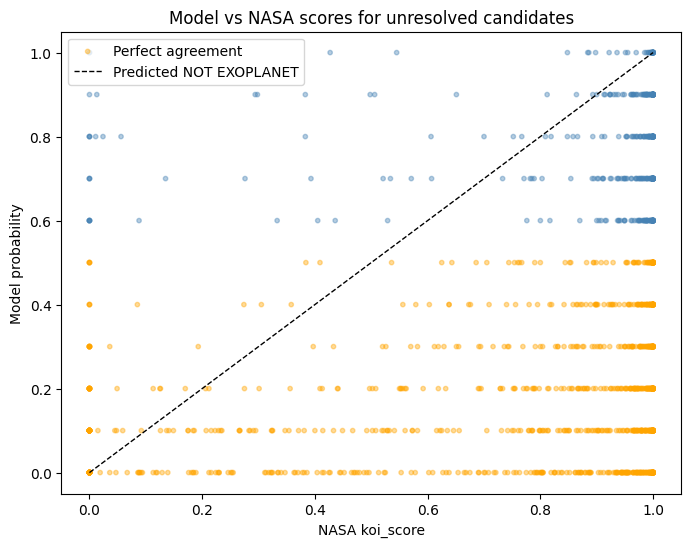

In [76]:
# SCATTER PLOTS FOR RFC CANDIDATES
cand_prob = pipeline.predict_proba(X_cand)[:,1]
plt.figure(figsize=(8,6))
colors = ['orange' if p == 0 else 'steelblue' for p in cand_pred]
plt.scatter(koi_scores_cand, cand_prob, c=colors, alpha=0.4, s=10)
plt.plot([0,1],[0,1], 'k--', linewidth=1, label='Perfect agreement')
plt.xlabel("NASA koi_score")
plt.ylabel("Model probability")
plt.title("Model vs NASA scores for unresolved candidates")
plt.legend(['Perfect agreement', 'Predicted NOT EXOPLANET', 'Predicted EXOPLANET'])
plt.show()

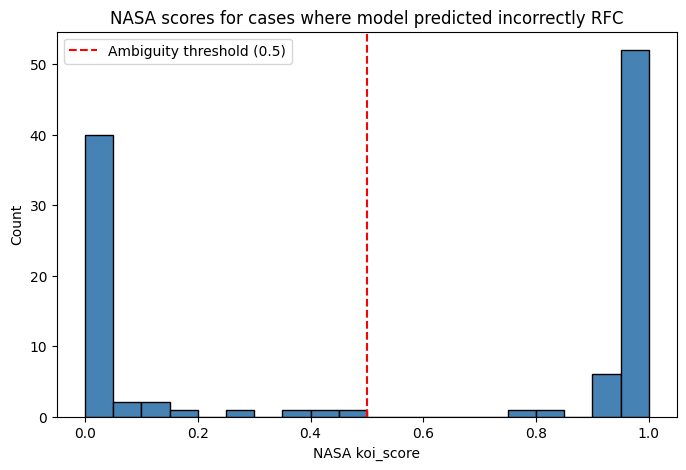

In [80]:
# HISTOGRAM WITH NASA SCORES WHERE RFC MODEL FAILED
y_pred = pipeline.predict(X_test)
wrong_mask = y_pred != y_test.values
wrong_nasa_scores = koi_scores_test[wrong_mask]
plt.figure(figsize=(8,5))
plt.hist(wrong_nasa_scores, bins=20, color='steelblue', edgecolor='black')
plt.axvline(x=0.5, color='red', linestyle='--', label='Ambiguity threshold (0.5)')
plt.xlabel("NASA koi_score")
plt.ylabel("Count")
plt.title("NASA scores for cases where model predicted incorrectly RFC")
plt.legend()
plt.show()

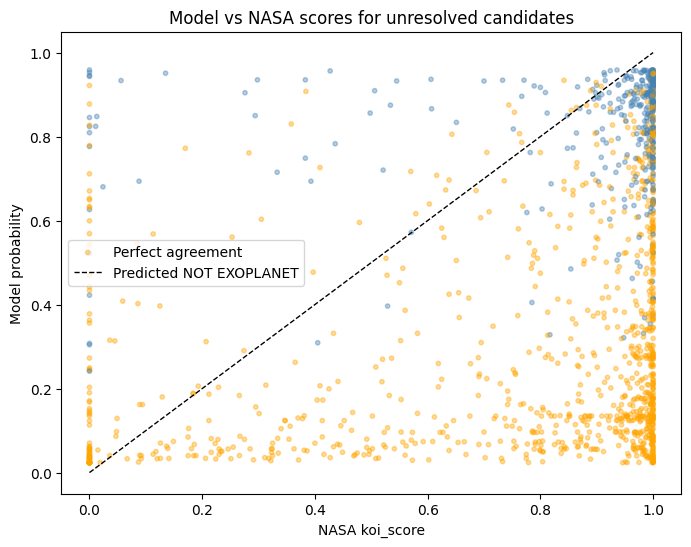

In [ ]:
cand_prob = xgb_pipe.predict_proba(X_cand)[:,1]
plt.figure(figsize=(8,6))
colors = ['orange' if p == 0 else 'steelblue' for p in cand_pred]
plt.scatter(koi_scores_cand, cand_prob, c=colors, alpha=0.4, s=10)
plt.plot([0,1],[0,1], 'k--', linewidth=1, label='Perfect agreement')
plt.xlabel("NASA koi_score")
plt.ylabel("Model probability")
plt.title("Model vs NASA scores for unresolved candidates")
plt.legend(['Perfect agreement', 'Predicted NOT EXOPLANET', 'Predicted EXOPLANET'])
plt.show()

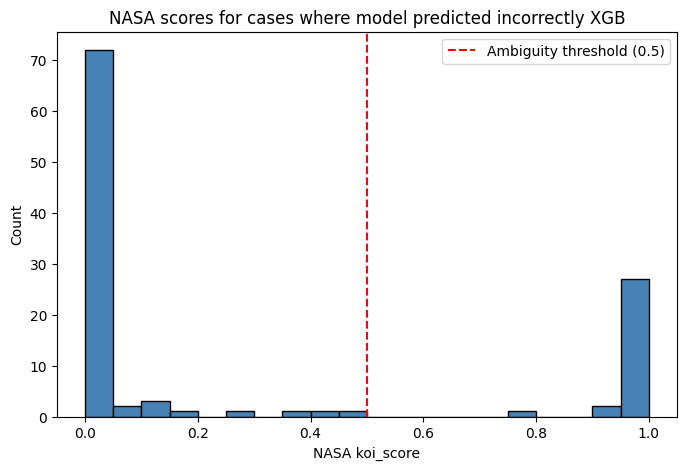

In [81]:
# HISTOGRAM WITH NASA SCORES WHERE RFC MODEL FAILED
y_pred = xgb_pipe.predict(X_test)
wrong_mask = y_pred != y_test.values
wrong_nasa_scores = koi_scores_test[wrong_mask]
plt.figure(figsize=(8,5))
plt.hist(wrong_nasa_scores, bins=20, color='steelblue', edgecolor='black')
plt.axvline(x=0.5, color='red', linestyle='--', label='Ambiguity threshold (0.5)')
plt.xlabel("NASA koi_score")
plt.ylabel("Count")
plt.title("NASA scores for cases where model predicted incorrectly XGB")
plt.legend()
plt.show()

In [84]:
# SHAP FOR PREDICTABILITY
import shap

In [86]:
explainer = shap.TreeExplainer(xgb_pipe.named_steps['xgb_model'])
# need the imputed data, not raw X_test
X_test_imputed = pipeline.named_steps['imputer'].transform(X_test)
shap_values = explainer.shap_values(X_test_imputed)

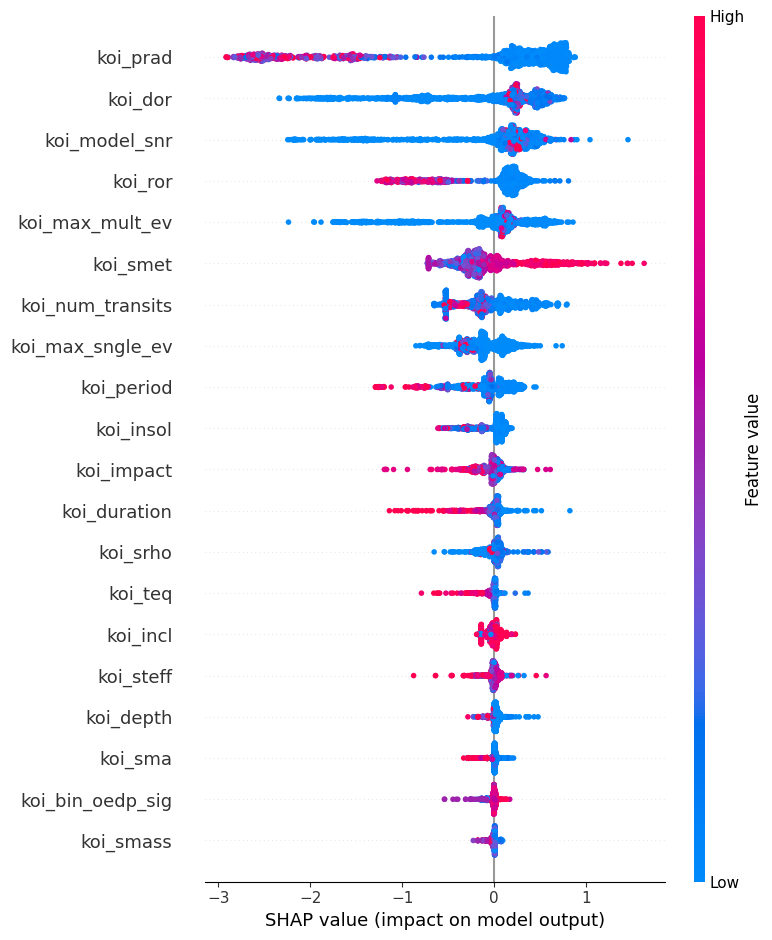

In [87]:
shap.summary_plot(shap_values, X_test_imputed, feature_names=X_test.columns)

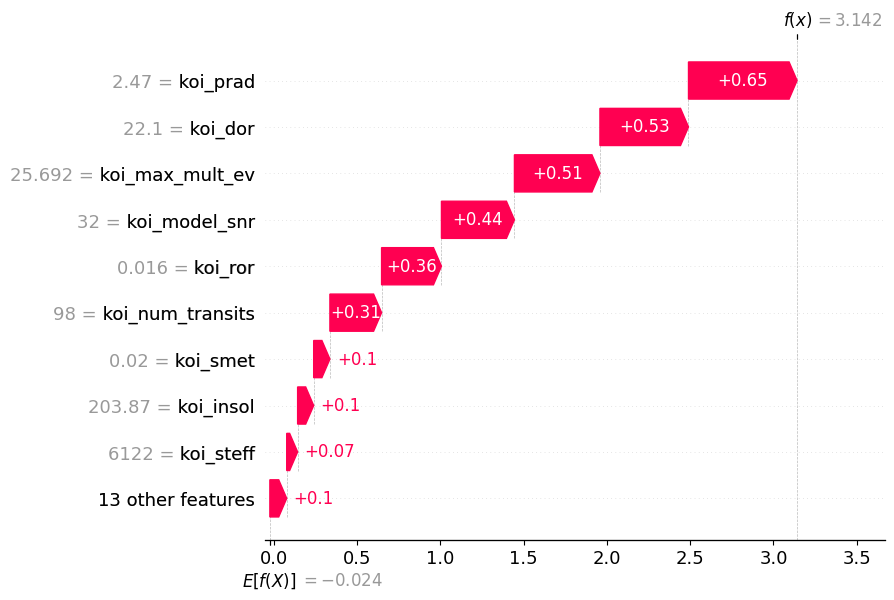

In [88]:
# find the test sample that the model is most confident is a planet
test_prob = xgb_pipe.predict_proba(X_test)[:,1]
most_confident_idx = test_prob.argmax()  # you'd need predict_proba on X_test
shap.plots.waterfall(shap.Explanation(values=shap_values[most_confident_idx], 
                     base_values=explainer.expected_value,
                     data=X_test_imputed[most_confident_idx],
                     feature_names=X_test.columns.tolist()))

In [92]:
df_cand

,koi_period,koi_impact,prediction_prob,prediction,koi_duration,koi_depth,koi_ror,koi_srho,koi_prad,koi_sma,...,koi_max_sngle_ev,koi_max_mult_ev,koi_model_snr,koi_num_transits,koi_bin_oedp_sig,koi_steff,koi_slogg,koi_smet,koi_srad,koi_smass
2,19.899140,0.969,0.0,NOT EXOPLANET,1.7822,10829.0,0.154046,7.29555,14.60,0.1419,...,37.159767,187.449100,76.3,56.0,0.6624,5853.0,4.544,-0.18,0.868,0.961
58,40.419504,0.911,0.3,NOT EXOPLANET,3.3620,6256.0,0.088069,1.89549,7.51,0.2062,...,22.598503,94.071846,36.9,36.0,0.8482,5446.0,4.507,-0.54,0.781,0.714
62,7.240661,1.198,0.3,NOT EXOPLANET,0.5580,556.4,0.232818,8.66412,19.45,0.0692,...,3.275137,9.166600,13.7,168.0,0.4049,5005.0,4.595,0.14,0.765,0.850
63,3.435916,0.624,0.2,NOT EXOPLANET,3.1330,23.2,0.004612,0.47024,0.55,0.0437,...,3.894302,7.433781,8.7,357.0,0.0228,5779.0,4.339,-0.06,1.087,0.941
84,10.181584,0.920,0.1,NOT EXOPLANET,3.5089,5741.1,0.084708,0.38059,7.73,0.0884,...,27.099031,173.098940,183.6,129.0,0.5397,5988.0,4.541,-0.52,0.836,0.885
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9538,7.268182,0.780,0.1,NOT EXOPLANET,4.9850,46.7,0.006856,0.13021,1.66,0.0821,...,3.426690,7.831779,9.7,183.0,0.0359,6297.0,3.890,0.00,2.219,1.398
9542,376.379890,0.305,0.0,NOT EXOPLANET,13.9900,1140.0,0.031308,1.10893,3.26,1.0287,...,5.646719,7.345223,13.3,3.0,0.1431,6231.0,4.488,-0.32,0.955,1.025
9552,367.947848,0.902,0.1,NOT EXOPLANET,4.2490,1301.0,0.039795,5.58716,3.72,0.9955,...,4.872857,8.615878,10.7,4.0,0.4002,5570.0,4.561,0.07,0.855,0.971
9560,1.739849,0.043,0.2,NOT EXOPLANET,3.1140,48.5,0.006379,0.50770,0.72,0.0290,...,3.841146,8.569540,10.6,766.0,0.1374,6119.0,4.444,-0.04,1.031,1.075


In [ ]:
exo_preds = df_cand[df_cand["prediction"] == "EXOPLANET"]


In [109]:
sub_nept_preds = exo_preds[(1.7 < exo_preds["koi_prad"]) & (exo_preds["koi_prad"] < 3.5)]
sub_nept_preds["kepoi_name"] = df_misc[raw_df["koi_disposition"] == "CANDIDATE"].loc[sub_nept_preds.index, "kepoi_name"].values

In [112]:
sub_nept_preds[["kepoi_name", "koi_prad", "prediction_prob"]]

,kepoi_name,koi_prad,prediction_prob
253,K00914.01,1.87,0.9
269,K00928.01,2.42,0.7
349,K00974.01,2.52,0.8
405,K01118.01,2.67,0.7
458,K00994.01,2.12,0.7
...,...,...,...
7277,K01628.03,1.76,1.0
7569,K00266.02,1.74,0.7
7584,K02828.02,3.46,0.8
8091,K06409.01,2.42,0.6


<Axes: xlabel='koi_prad', ylabel='Count'>

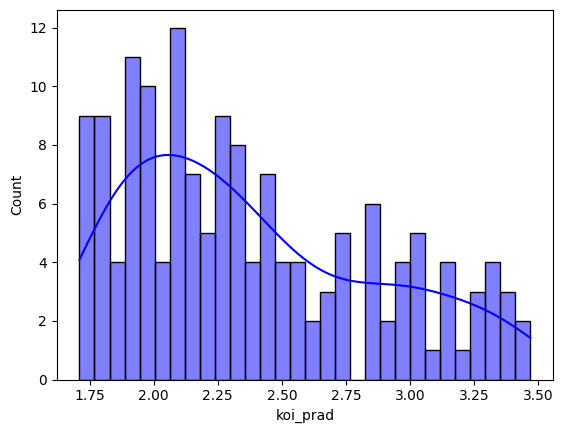

In [115]:
sns.histplot(data=sub_nept_preds, x='koi_prad', bins=30, kde=True, color='blue')

In [117]:
# CONFIRMED PLANETS TABLE COMPARISON
confirmed_planets = pd.read_csv("PS_2026.03.10_13.53.22.csv", comment="#")
confirmed_planets

/var/folders/9b/bvt00_8x1hjcd35fry7fqxxh0000gn/T/ipykernel_31301/2402989633.py:2: DtypeWarning: Columns (0: hd_name, 1: hip_name) have mixed types. Specify dtype option on import or set low_memory=False.
  confirmed_planets = pd.read_csv("PS_2026.03.10_13.53.22.csv", comment="#")


,rowid,pl_name,hostname,pl_letter,hd_name,hip_name,tic_id,gaia_dr2_id,gaia_dr3_id,default_flag,...,rowupdate,pl_pubdate,releasedate,pl_nnotes,st_nphot,st_nrvc,st_nspec,pl_nespec,pl_ntranspec,pl_ndispec
0,1,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,1,...,2023-09-19,2023-08,2023-09-19,2.0,1.0,2.0,0.0,0.0,0.0,0.0
1,2,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,0,...,2014-05-14,2008-01,2014-05-14,2.0,1.0,2.0,0.0,0.0,0.0,0.0
2,3,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,0,...,2014-07-23,2011-08,2014-07-23,2.0,1.0,2.0,0.0,0.0,0.0,0.0
3,4,11 UMi b,11 UMi,b,HD 136726,HIP 74793,TIC 230061010,Gaia DR2 1696798367260229376,Gaia DR3 1696798367260229376,0,...,2018-04-25,2009-10,2014-05-14,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4,5,11 UMi b,11 UMi,b,HD 136726,HIP 74793,TIC 230061010,Gaia DR2 1696798367260229376,Gaia DR3 1696798367260229376,1,...,2018-09-04,2017-03,2018-09-06,0.0,1.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39471,39472,ups And d,ups And,d,HD 9826,HIP 7513,TIC 189576919,Gaia DR2 348020448377061376,Gaia DR3 348020482735930112,0,...,2021-09-20,2021-07,2021-09-20,5.0,1.0,10.0,1.0,0.0,0.0,0.0
39472,39473,ups Leo b,ups Leo,b,NaN,NaN,TIC 49430557,Gaia DR2 3794167001116433152,Gaia DR3 3794167001116704000,1,...,2022-01-10,2021-12,2022-01-10,0.0,0.0,0.0,0.0,0.0,0.0,0.0
39473,39474,xi Aql b,xi Aql,b,HD 188310,HIP 97938,TIC 375464367,Gaia DR2 4298361114750843904,Gaia DR3 4298361114753012992,0,...,2014-07-23,2011-08,2014-07-23,1.0,1.0,1.0,0.0,0.0,0.0,0.0
39474,39475,xi Aql b,xi Aql,b,HD 188310,HIP 97938,TIC 375464367,Gaia DR2 4298361114750843904,Gaia DR3 4298361114753012992,0,...,2014-05-14,2008-06,2014-05-14,1.0,1.0,1.0,0.0,0.0,0.0,0.0


In [119]:
confirmed_planets.columns

Index(['rowid', 'pl_name', 'hostname', 'pl_letter', 'hd_name', 'hip_name',
       'tic_id', 'gaia_dr2_id', 'gaia_dr3_id', 'default_flag',
       ...
       'rowupdate', 'pl_pubdate', 'releasedate', 'pl_nnotes', 'st_nphot',
       'st_nrvc', 'st_nspec', 'pl_nespec', 'pl_ntranspec', 'pl_ndispec'],
      dtype='str', length=123)

In [ ]:
confirmed_preds = pd.merge(sub_nept_preds, confirmed_planets, on="kepoi_name")

In [122]:
df_misc["kepler_name"]

0       Kepler-227 b
1       Kepler-227 c
2                NaN
3                NaN
4       Kepler-664 b
            ...     
9559             NaN
9560             NaN
9561             NaN
9562             NaN
9563             NaN
Name: kepler_name, Length: 9564, dtype: str

In [120]:
# get kepler_name for  candidate predictions
cand_kepler_names = df_misc[raw_df["koi_disposition"] == "CANDIDATE"].loc[sub_nept_preds.index, "kepler_name"].values
matches = confirmed_planets[confirmed_planets["pl_name"].isin(cand_kepler_names)]
print(matches[["pl_name", "disc_year", "pl_rade"]])

Empty DataFrame
Columns: [pl_name, disc_year, pl_rade]
Index: []


In [124]:
[c for c in confirmed_planets.columns if 'koi' in c.lower()]

[]